# Лекция 1. Первое знакомство с данными

Попробуем на примере разобрать то, о чём говорили на лекции: **зададим вопрос к данным кодом и получим на него ответ**.

1. Загрузим таблицу с отчётностью американских банков.
2. Посмотрим на неё: что внутри, что с ней не так, что с чем связано.
3. Объясним прибыльность банка линейной регрессией и увидим, чего простая регрессия сказать не может.
4. Сравним линейную регрессию с регрессией методом ближайших соседей: моделью, которая не предполагает никакой формулы.

Как работать с ноутбуком: ячейки запускаются сверху вниз, по `Shift+Enter`. Если пропустить ячейку, следующая, скорее всего, сломается: переменные создаются по порядку.

## 0. Подготовка

Эта ячейка есть в каждом ноутбуке курса. Она подключает библиотеки и говорит, откуда брать данные. Запустите её первой.

**Библиотека** — набор чужого готового кода, который мы берём и используем. `import pandas as pd` означает «подключи библиотеку `pandas` и дальше называй её коротко `pd`».

In [1]:
# Библиотеки. Импортируем один раз в начале — дальше они доступны во всём ноутбуке.
# Клеточка "живет", пока активен ноутбук, поэтому при его перезапуске нужно будет снова выполнить эту клеточку
import numpy as np                 # массивы и математика
import pandas as pd                # таблицы: главный инструмент курса
import matplotlib.pyplot as plt    # рисование графиков
import seaborn as sns              # графики покрасивее, надстройка над matplotlib

# Откуда берём данные: файлы лежат в репозитории курса, читаем их прямо по ссылке.
# спойлер: для этого нужен интернет
DATA = "https://raw.githubusercontent.com/nvvoitov/da_intro/main/data/"

# Фиксируем случайность (сид): одно и то же число -> одинаковый результат при перезапуске
# без сида все функции, где есть случайность, будут выдавать разные результаты
SEED = 20260101

# Косметика: параметры для отображения графиков. Вникать не обязательно.
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)     # размер картинки по умолчанию
pd.set_option("display.max_columns", 30)    # показывать до 30 колонок таблицы

## 1. Импорт данных

Данные о банках США собирает FDIC, американский аналог АСВ. Он публикует квартальную отчётность каждого банка и список банкротств. Мы берём оттуда 2001–2026 годы: все банки, которые за это время обанкротились, плюс случайную выборку продолживших деятельность. Поэтому банкротств в нашей таблице намного больше, чем среди всех американских банков, — об этом подробно в четвёртой лекции.

Файл лежит в формате **parquet**. Он похож на csv, только данные хранятся в двоичном виде: файл меньше, читается быстрее, и типы колонок (число, дата, текст) сохраняются сами. Читаем его командой `pd.read_parquet` (для `csv` есть `pd.read_csv`).

Денежные величины указаны в тысячах долларов.

In [2]:
# Создаём переменную panel, в которой будет лежать вся таблица.
# Знак + склеивает адрес папки и имя файла в одну ссылку.
# осторожно: файл большой, поэтому загрузка может занять несколько секунд
panel = pd.read_parquet(DATA + "banks_panel.parquet")

In [3]:
# вы можете сохранить файлик локально для работы в будущем так:
# panel.to_parquet("banks_panel.parquet")

Ячейка выше ничего не напечатала: она просто положила таблицу в переменную. Чтобы что-то увидеть, надо об этом попросить.

Начнём с размера: `.shape` возвращает пару чисел, число строк и число колонок.

In [4]:
# .shape — это не команда, а свойство таблицы: пара (строки, колонки)
print("строк и колонок:", panel.shape)

# len() считает строки, .nunique() — сколько уникальных значений в колонке
print("строк (банк-квартал):", len(panel))
print("разных банков:", panel["cert"].nunique())

# .min() и .max() по колонке с датой отчётности
print("период:", panel["repdte"].min().date(), "..", panel["repdte"].max().date())

строк и колонок: (152152, 42)
строк (банк-квартал): 152152
разных банков: 2586
период: 2001-03-31 .. 2026-06-30


Обратите внимание: строк 152 тысячи, а банков 2.5 тысячи. Один банк встречается в таблице много раз, по разу на каждый квартал.

**Одна строка = один банк в один квартал.** Знакомый нам вид панельных данных.

Теперь посмотрим на несколько строк глазами. `.head()` показывает первые 5.

In [5]:
# В двойных квадратных скобках — список колонок, которые хотим увидеть.
# Без него напечатались бы все 42 колонки, и читать было бы неудобно.
panel[["cert", "name", "state", "repdte", "assets", "equity", "net_income"]].head()

,cert,name,state,repdte,assets,equity,net_income
0,41,Phenix-Girard Bank,AL,2001-03-31,106506.0,14180.0,468.0
1,41,Phenix-Girard Bank,AL,2001-06-30,107577.0,14556.0,458.0
2,41,Phenix-Girard Bank,AL,2001-09-30,104196.0,15379.0,603.0
3,41,Phenix-Girard Bank,AL,2001-12-31,106383.0,14756.0,317.0
4,41,Phenix-Girard Bank,AL,2002-03-31,104151.0,14906.0,585.0


Что в колонках:

* `cert` — номер лицензии FDIC, **идентификатор банка**: название может поменяться, номер остаётся;
* `repdte` — дата отчётности (конец квартала);
* `assets`, `equity`, `net_income` — активы, капитал, прибыль, в тысячах долларов.

Работать с абсолютными значениями неудобно: банк на 300 миллионов и банк на 300 миллиардов несравнимы. Поэтому в таблице уже посчитаны **отношения** (ratio): суммы, поделённые на масштаб банка. Это знакомые нам показатели CAMELS:

| Префикс | Метрика | Пример |
|---|---|---|
| `c_` | капитал | `c_equity_assets` = капитал / активы |
| `a_` | качество активов | `a_npl_gross_loans` = просрочка / кредиты |
| `m_` | эффективность | `m_cost_income` = непроцентные расходы / чистый процентный доход |
| `e_` | прибыльность | `e_roa` = прибыль / активы |
| `l_` | ликвидность | `l_loans_deposits` = кредиты / депозиты |
| `s_` | рыночный риск | `s_securities_assets` = ценные бумаги / активы |

Полный список колонок выводит команда `.columns`.

In [6]:
# list() превращает результат в обычный список, его удобнее читать и, например, копировать
print(list(panel.columns))

['cert', 'repdte', 'assets', 'deposits', 'equity', 'loans_gross', 'llr', 'npl', 'securities', 'brokered_deposits', 'tier1_capital', 'cash', 'cre_loans', 'net_income', 'nii', 'noninterest_exp', 'nco', 'name', 'state', 'charter_class', 'fail_date', 'failed_next_4q', 'failed_next_8q', 'censored', 'c_equity_assets', 'c_tier1_leverage', 'c_equity_growth_yoy', 'a_npl_gross_loans', 'a_llr_npl_coverage', 'a_nco_rate', 'a_cre_concentration', 'm_cost_income', 'm_asset_growth_yoy', 'm_growth_vs_peer_median', 'e_roa', 'e_roe', 'e_nim', 'e_earnings_vol_8q', 'l_liquid_assets_ratio', 'l_loans_deposits', 'l_brokered_share', 's_securities_assets']


## 2. Как «посмотреть» на данные

У нас 152 тысячи строк. Открыть их глазами нельзя, поэтому смотреть будем на статистики и картинки. Порядок почти всегда один и тот же:

1. что за колонки и есть ли пропуски: `.info()`;
2. описательная статистика: `.describe()`;
3. распределение каждой переменной по отдельности: гистограммы;
4. связи между переменными: диаграммы рассеяния и корреляции.

### 2.1 Что за колонки

In [7]:
# .info() печатает: имя колонки, сколько непустых значений, тип данных
panel.info()

<class 'pandas.DataFrame'>
RangeIndex: 152152 entries, 0 to 152151
Data columns (total 42 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   cert                     152152 non-null  int32         
 1   repdte                   152152 non-null  datetime64[ns]
 2   assets                   152152 non-null  float64       
 3   deposits                 152152 non-null  float64       
 4   equity                   152088 non-null  float64       
 5   loans_gross              152152 non-null  float64       
 6   llr                      152088 non-null  float64       
 7   npl                      152152 non-null  float64       
 8   securities               152152 non-null  float64       
 9   brokered_deposits        152088 non-null  float64       
 10  tier1_capital            152088 non-null  float64       
 11  cash                     152152 non-null  float64       
 12  cre_loans                15

В выводе две главные колонки. `Non-Null Count` показывает, сколько значений заполнено; где меньше 152 152, там **пропуски**. У `fail_date` они почти везде: она заполнена только у банков, которые действительно упали. `Dtype` — тип: `float64`/`float32` — число, `datetime64` — дата, `bool` — да/нет, `string`/`category` — текст.

Тип важен: числа можно складывать и умножать, даты сравнивать, текст разбирать на части.

### 2.2 Числовые сводки

In [8]:
# .describe() считает меры центральной тенденции и изменчивости
# .T переворачивает таблицу (колонки становятся строками) — так читать удобнее.
# .round(3) округляет до 3 знаков.
panel[["assets", "e_roa", "c_equity_assets", "a_npl_gross_loans",
       "m_cost_income", "l_loans_deposits"]].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
assets,152152.0,1726016.146,2.242061e+07,68.000,71265.750,159599.500,405439.500,1.470277e+09
e_roa,149503.0,0.008,3.300000e-02,-1.107,0.004,0.009,0.013,1.352000e+00
c_equity_assets,152088.0,0.122,1.100000e-01,-0.445,0.085,0.100,0.122,1.000000e+00
a_npl_gross_loans,149601.0,0.017,3.300000e-02,0.000,0.002,0.007,0.018,1.000000e+00
m_cost_income,151626.0,4.527,1.290150e+02,-19496.000,0.682,0.820,0.998,2.065300e+04
l_loans_deposits,150446.0,10.085,5.744170e+02,0.000,0.643,0.797,0.925,6.841895e+04


Смотрим на края (`min` и `max`). `m_cost_income` — непроцентные расходы, делённые на чистый процентный доход; у обычного банка значение лежит в диапазоне 0.5–1.0. А в таблице минимум −19 496 и максимум 20 653.

Ошибки FDIC здесь нет. Это банки, у которых чистый процентный доход почти ноль или отрицательный: трастовые компании, карточные банки, банки в процессе ликвидации. Деление на «почти ноль» даёт «почти бесконечность».

Такие значения ломают и графики, и модели. Давайте посмотрим.

### 2.3 Распределения

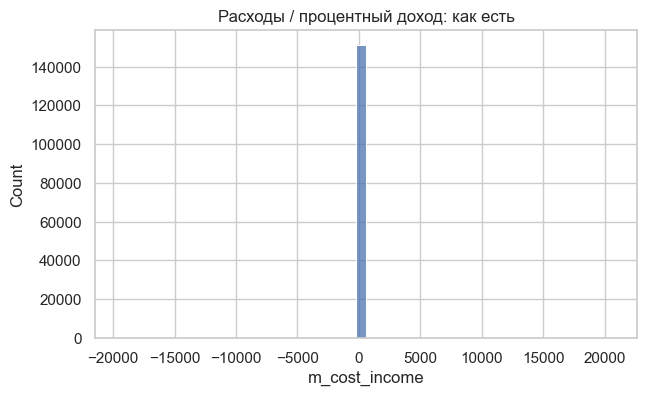

In [9]:
# Гистограмма: по горизонтали — значение, по вертикали — сколько банк-кварталов попало в этот интервал.
sns.histplot(
    # таблица, которую визуализируем
    data=panel, 
    # колонка из таблицы
    x="m_cost_income", 
    # количество интервалов, можно менять
    bins=50)
plt.title("Расходы / процентный доход: как есть")
plt.show()

График неинформативен: один столбик у нуля и пустота на всю ширину. Виноваты те самые выбросы: из-за них ось растянута на 40 тысяч единиц, а все обычные банки слиплись в одну палку.

Посмотрим на ту же переменную в разумных границах. Иначе говоря, почистим данные для картинки:

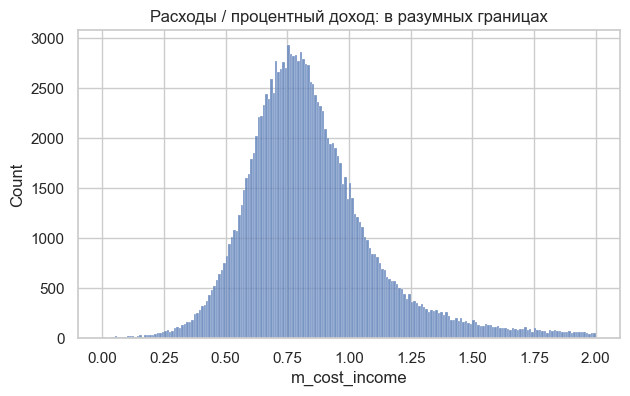

In [10]:
# binrange=(0, 2) — рисуем только интервал от 0 до 2, остальное игнорируем
sns.histplot(
    data=panel, 
    x="m_cost_income", 
    # Взяли больше бинов
    bins=200, 
    # Наш фильтр
    binrange=(0, 2))
plt.title("Расходы / процентный доход: в разумных границах")
plt.show()

Вот теперь видно распределение: горб около 0.8, длинный хвост справа.

Теперь мы хотим построить гистограмму не для одной колонки, а для нескольких. Копировать три строки шесть раз — плохая идея (шесть мест, где можно ошибиться). Для этого есть **цикл** `for`: он выполняет одни и те же действия для каждого элемента списка.

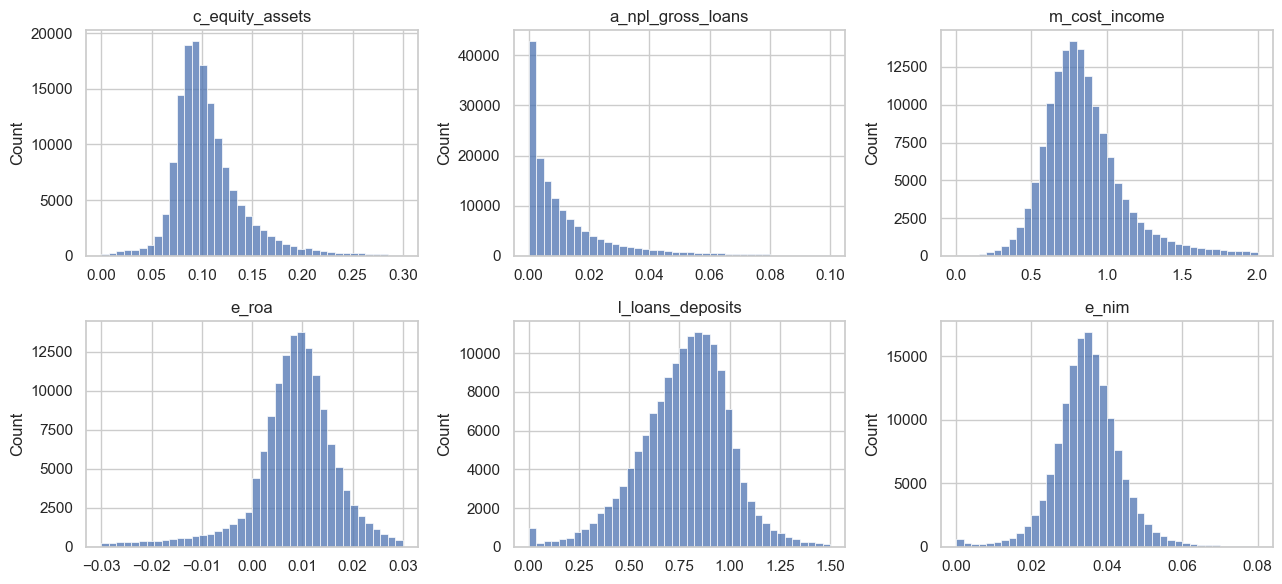

In [11]:
# Список колонок и границ (наших фильтров) для каждой: (имя колонки, от, до)
COLS = [("c_equity_assets",   0, 0.3),
        ("a_npl_gross_loans", 0, 0.1),
        ("m_cost_income",     0, 2.0),
        ("e_roa",         -0.03, 0.03),
        ("l_loans_deposits",  0, 1.5),
        ("e_nim",             0, 0.08)]

# plt.subplots(2, 3) создаёт сетку 2 строки на 3 колонки. axes — массив из шести "холстов".
fig, axes = plt.subplots(2, 3, figsize=(13, 6))

# .ravel() вытягивает сетку 2x3 в один список из 6 элементов, чтобы идти по ним подряд.
# zip() ставит в пару каждую колонку и её холст.
for (col, lo, hi), ax in zip(COLS, axes.ravel()):
    sns.histplot(data=panel, x=col, bins=40, binrange=(lo, hi), ax=ax)
    ax.set_title(col)          # заголовок каждой картинки
    ax.set_xlabel("")          # подпись оси не нужна, она дублирует заголовок

plt.tight_layout()             # чтобы подписи не наезжали друг на друга
plt.show()

Шесть картинок написаны один раз. Захотим седьмую — добавим строчку в `COLS`, код менять не надо.

### 2.4 Чистка данных

Пока что мы чистили выбросы только для картинки и не трогали сами данные. Но модель их увидит: она посчитает и банк с `m_cost_income = 20 653` наравне с остальными. Значит, решение надо принять явно: прописать, что фильтруем, и применить правила к таблице.

In [12]:
# Оставляем строки, где выполнены ВСЕ условия сразу.
# & означает "и". Каждое условие в своих скобках — это требование pandas.
banks = panel[
    (panel["assets"] > 50_000)                          # больше 50 млн $: не микроструктура
    & panel["e_roa"].between(-0.10, 0.10)               # ROA от -10% до +10% годовых
    & panel["m_cost_income"].between(0, 2)              # непроцентные расходы от 0 до 2 чистых процентных доходов
    & panel["a_nco_rate"].between(0, 0.05)              # списания от 0 до 5% кредитов
    & panel["c_equity_assets"].between(0.02, 0.30)      # капитал от 2% до 30% активов
].copy()                                                # .copy() — работаем с копией, не с куском исходной таблицы

print("было строк:  ", len(panel))
print("осталось:    ", len(banks), f"({len(banks) / len(panel):.0%})")
print("банков:      ", banks["cert"].nunique())

было строк:   152152
осталось:     95610 (63%)
банков:       2267


Отброшено больше трети строк. Мы только что поменяли совокупность, о которой будем делать выводы: дальше все наши утверждения относятся к «обычным работающим банкам», а не ко всем учреждениям с лицензией FDIC. Если такие выводы переносят на банки вне отбора, возникает **смещение отбора** (selection bias).

Одно условие особенное: ROA от −10 % до +10 %. ROA — это отклик наших будущих моделей, а фильтр по самому отклику отбирает строки по зависимой переменной. Такой отбор может сдвигать коэффициенты регрессии (в эконометрике это называют усечённой выборкой, truncation). Держите это в голове, когда будете читать коэффициенты ниже.

Такие моменты необходимо явно обозначать и в работе, и в учебных проектах: от фильтрации исходных данных выводы могут существенно меняться.

### 2.5 Связи между переменными

Одна переменная — гистограмма. Две переменные — **диаграмма рассеяния** (scatter): каждая точка это один банк-квартал. Это самый простой способ увидеть зависимость в данных.

152 тысячи точек рисовать не нужно: картинка превратится в кляксу, а ждать придётся долго. Возьмём случайные 3000 точек через `.sample()`.

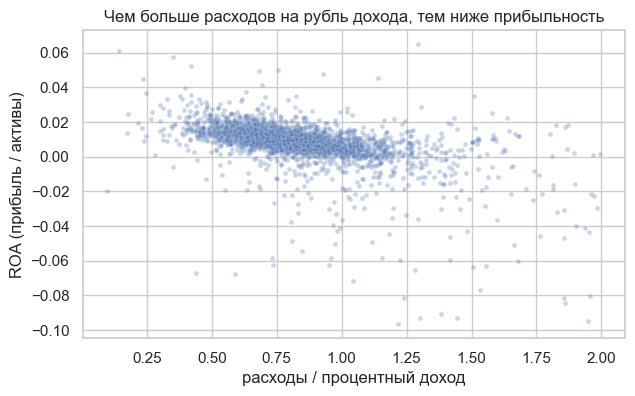

In [13]:
# random_state=SEED — сид из начала ноутбука: выборка будет одна и та же при каждом запуске
# можете заменить на другое число и посмотреть, как изменится график
# делаем случайную подвыборку
show = banks.sample(3000, random_state=SEED)

# alpha=0.3 — прозрачность точек: там, где их много, пятно темнее
sns.scatterplot(
    data=show, 
    x="m_cost_income", 
    y="e_roa", 
    alpha=0.3, 
    s=12)
plt.title("Чем больше расходов на рубль дохода, тем ниже прибыльность")
plt.xlabel("расходы / процентный доход")
plt.ylabel("ROA (прибыль / активы)")
plt.show()

Облако наклонено вниз: связь есть.

Чтобы не строить такую картинку для каждой пары из 20 показателей, есть **корреляционная матрица**: одно число на пару, от −1 до +1. `.corr()` её рассчитывает, `sns.heatmap` раскрашивает.

Проведём исследование корреляций в промышленном масштабе.

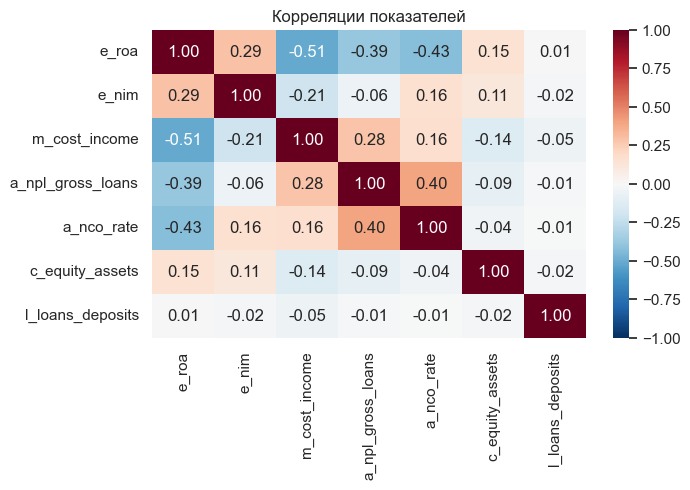

In [14]:
RATIOS = ["e_roa", "e_nim", "m_cost_income", "a_npl_gross_loans",
          "a_nco_rate", "c_equity_assets", "l_loans_deposits"]

# .corr() — таблица корреляций всех со всеми
corr = banks[RATIOS].corr()

# annot=True — писать числа в клетках; cmap — цветовая шкала; center=0 — белый цвет на нуле
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Корреляции показателей")
plt.show()

В первой строке видно, с чем связана прибыльность активов: с расходами к доходу — сильно отрицательно, с процентной маржой — положительно, со списаниями и просрочкой — отрицательно.

Всё это ожидаемо. Если бы знаки были другими, надо было бы искать ошибку в данных, а не открывать новый эмпирический банковский закон.

Последний приём EDA (exploratory data analysis) на сегодня — сравнение групп. `.groupby()` делит таблицу на части по значению колонки и считает что-нибудь внутри каждой части.

In [15]:
# failed_next_4q — обанкротился ли банк в ближайшие 4 квартала (True/False)
# .median() — медиана внутри каждой группы (медиана менее чувствительна к выбросам, чем среднее)
banks.groupby("failed_next_4q")[
    ["c_equity_assets", "a_npl_gross_loans", "e_roa", "m_cost_income"]
].median().round(4).T

failed_next_4q,False,True
c_equity_assets,0.0978,0.0561
a_npl_gross_loans,0.0073,0.0927
e_roa,0.0091,-0.0172
m_cost_income,0.8014,1.2203


Результат налицо: перед банкротством капитал вдвое меньше, просрочка в несколько раз выше, прибыль отрицательная. (Сравниваем только банки, прошедшие наш фильтр; он выбросил больше половины банкротств, но и оставшихся хватает для картины.)

Пока запомним главное: посмотреть на данные — значит ответить на несколько вопросов, одной командой здесь не обойтись. Стандартного шаблона нет, но стоит как минимум спросить себя:

- Что в колонках?
- Какой вид имеет распределение данных?
- Что с выбросами?
- Что с чем связано?

## 3. Линейная регрессия: как учесть взаимодействие

Поставим более формальный вопрос: с чем связана прибыльность банка?

Возьмём два показателя, которые, как мы ожидаем, с ней связаны:

* `a_nco_rate` — доля списанных кредитов (потери по портфелю);
* `c_equity_assets` — капитал к активам (запас прочности).

Модель, знакомая из эконометрики:

$$ \text{ROA} = \beta_0 + \beta_1 \cdot \text{списания} + \beta_2 \cdot \text{капитал} + \varepsilon $$

Считать её будем библиотекой `statsmodels`: она принимает формулу в том же виде, в каком вы её пишете на бумаге.

In [16]:
# smf — модуль statsmodels, который понимает формулы вида "y ~ x1 + x2"
import statsmodels.formula.api as smf

# ols = ordinary least squares, обычный МНК. Слева от ~ зависимая переменная, справа независимые переменные через +.
# .fit() запускает оценивание (фитит модель) и возвращает результат
model_simple = smf.ols("e_roa ~ a_nco_rate + c_equity_assets", data=banks).fit()

# .summary().tables[1] — та самая таблица коэффициентов со стандартными ошибками и t
print(model_simple.summary().tables[1])
print("R^2 =", round(model_simple.rsquared, 4))

                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.0048      0.000     39.830      0.000       0.005       0.005
a_nco_rate         -1.6844      0.012   -145.464      0.000      -1.707      -1.662
c_equity_assets     0.0500      0.001     45.848      0.000       0.048       0.052
R^2 = 0.2


Знаки осмысленные: списания тянут прибыльность вниз, капитал вверх. $t$-статистики огромные, и это эффект объёма: при 95 тысячах наблюдений значимо почти всё. К тому же стандартные ошибки здесь занижены: кварталы одного банка не независимы, об этом во второй лекции. Смотреть надо на величину коэффициента.

Коэффициенты выражены в долях единицы, поэтому переведём их в понятные величины: рост списаний на 1 процентный пункт — это +0.01 по `a_nco_rate`.

In [17]:
# .params — коэффициенты модели, обращаемся к нужному по имени
b_nco = model_simple.params["a_nco_rate"]
b_cap = model_simple.params["c_equity_assets"]

# 0.01 — один процентный пункт; 10 000 — перевод доли ROA в базисные пункты
print(f"+1 п.п. списаний ->  {b_nco * 0.01 * 10_000:+.0f} б.п. ROA")
print(f"+1 п.п. капитала ->  {b_cap * 0.01 * 10_000:+.0f} б.п. ROA")

+1 п.п. списаний ->  -168 б.п. ROA
+1 п.п. капитала ->  +5 б.п. ROA


Нарисуем то, что посчитали. `sns.regplot` строит облако точек и проводит через него линию МНК.

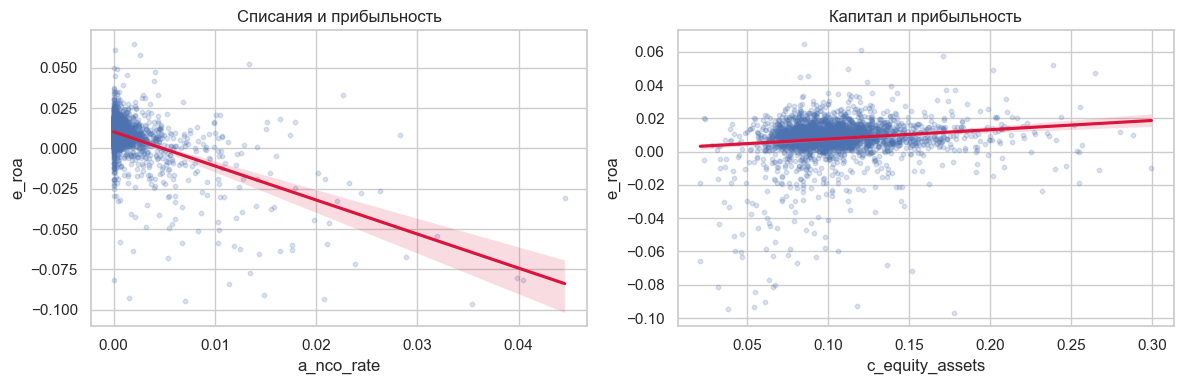

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.regplot(data=show, x="a_nco_rate", y="e_roa", ax=axes[0],
            scatter_kws={"alpha": 0.2, "s": 10},   # как рисовать точки
            line_kws={"color": "crimson"})          # как рисовать линию
axes[0].set_title("Списания и прибыльность")

sns.regplot(data=show, x="c_equity_assets", y="e_roa", ax=axes[1],
            scatter_kws={"alpha": 0.2, "s": 10}, line_kws={"color": "crimson"})
axes[1].set_title("Капитал и прибыльность")

plt.tight_layout()
plt.show()

### Чего эта модель сказать не может

Доверительная полоса вокруг линии расширяется к краям. Это обычное свойство МНК: у краёв мало точек, и положение прямой там известно хуже. О том, одинаков ли наклон для всех банков, полоса ничего не говорит.

А регрессия предполагает именно это: один коэффициент $\beta_1$ для всех наблюдений — и для банка с капиталом в 4 % активов, и для банка с капиталом в 20 %. Экономически это сомнительно. У банка с небольшим капиталом списания редко происходят в вакууме: скорее всего, доначисляются резервы, дорожает фондирование, уходят клиенты. У банка с толстым капиталом тот же процент списаний может почти не отразиться на операционной деятельности.

Проверим гипотезу глазами: разобьём банки на три группы по капиталу и проведём линию внутри каждой группы.

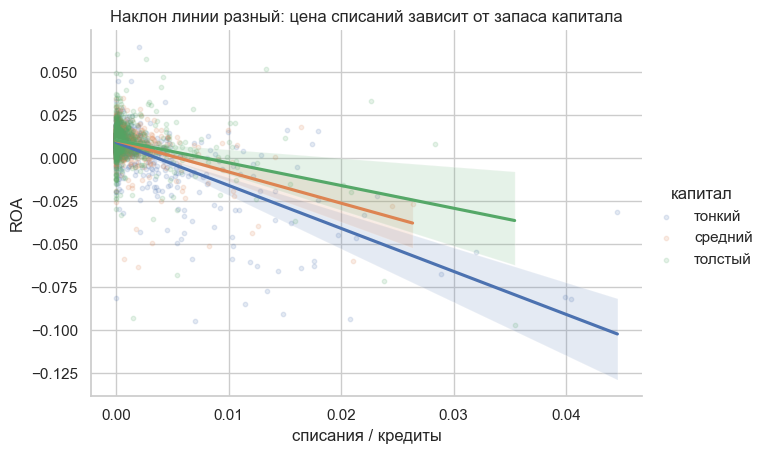

In [19]:
# pd.qcut делит на 3 равные по числу наблюдений группы (по терцилям) и подписывает их
show = show.copy()
show["капитал"] = pd.qcut(show["c_equity_assets"], 3,
                          labels=["тонкий", "средний", "толстый"])

# lmplot рисует отдельную линию регрессии для каждой группы (hue = "раскрасить по")
sns.lmplot(data=show, x="a_nco_rate", y="e_roa", hue="капитал",
           height=4.5, aspect=1.5, 
           scatter_kws={"alpha": 0.15, "s": 10})
plt.title("Наклон линии разный: цена списаний зависит от запаса капитала")
plt.xlabel("списания / кредиты")
plt.ylabel("ROA")
plt.show()

Линии не параллельны. У банков с тонким капиталом наклон заметно круче: те же списания сопровождаются более сильным падением прибыльности.

Это и называется **эффектом взаимодействия**: влияние одного признака зависит от значения другого. В формулу он добавляется как произведение:

$$ \text{ROA} = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 \cdot (X_1 \times X_2) + \varepsilon $$

В `statsmodels` произведение пишется звёздочкой: `x1 * x2` означает «оба признака и их произведение». С математической точки зрения мы просто перемножаем колонки.

In [20]:
# Звёздочка = x1 + x2 + x1:x2. Двоеточие — это само произведение.
model_inter = smf.ols("e_roa ~ a_nco_rate * c_equity_assets", data=banks).fit()

print(model_inter.summary().tables[1])
print("R^2 без взаимодействия:", round(model_simple.rsquared, 4))
print("R^2 с взаимодействием: ", round(model_inter.rsquared, 4))

                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                      0.0087      0.000     71.237      0.000       0.008       0.009
a_nco_rate                    -3.7733      0.025   -151.681      0.000      -3.822      -3.725
c_equity_assets                0.0125      0.001     11.196      0.000       0.010       0.015
a_nco_rate:c_equity_assets    20.5810      0.219     93.789      0.000      20.151      21.011
R^2 без взаимодействия: 0.2
R^2 с взаимодействием:  0.2674


Коэффициент при произведении положителен: чем больше капитал, тем слабее связь списаний с прибыльностью. Мы перенесли наблюдение с картинки в формулу и оценили её.

### Как выглядит «скручивание пространства»

Модель с двумя признаками предсказывает ROA в каждой точке плоскости «списания × капитал», то есть задаёт поверхность над этой плоскостью. Пока в модели только слагаемые, поверхность остаётся плоскостью: наклон по списаниям один и тот же в любой её точке. Произведение снимает это ограничение, и поверхность начинает «гнуться».

Нарисуем обе поверхности рядом. Чёрные линии — три «среза» при фиксированном капитале: 6 %, 10 % и 17 %.

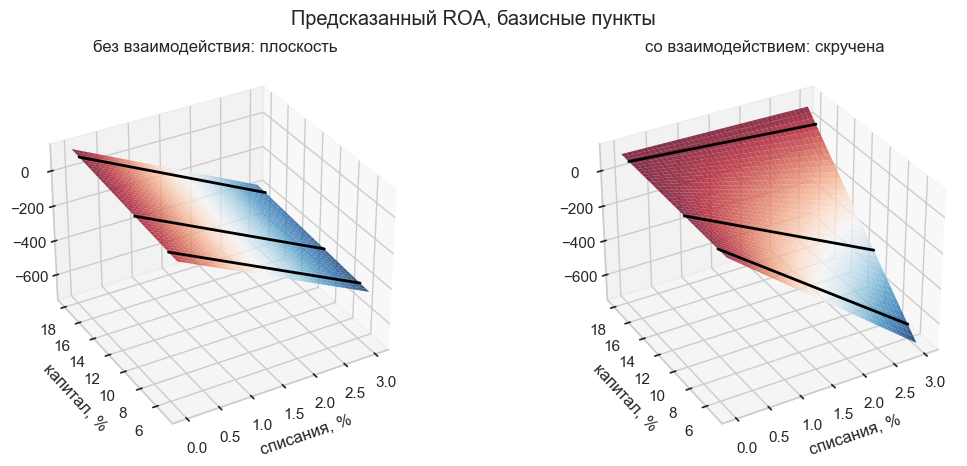

In [21]:
# Сетка: 40 значений списаний на 40 значений капитала = 1600 комбинаций
nco = np.linspace(0, 0.03, 40)
cap = np.linspace(0.05, 0.18, 40)
NCO, CAP = np.meshgrid(nco, cap)        # решётка из всех пар значений

# .predict() ждёт таблицу, поэтому вытягиваем решётку в два столбика
scen = pd.DataFrame({"a_nco_rate": NCO.ravel(), "c_equity_assets": CAP.ravel()})

# Своя маленькая функция: рисует на осях ax поверхность одной модели и три среза.
# Так мы пишем код один раз, а вызываем его дважды — для обеих моделей.
def surface(ax, model, title):
    # предсказания модели, свёрнутые обратно в форму решётки, в базисных пунктах
    Z = model.predict(scen).to_numpy().reshape(NCO.shape) * 10_000
    ax.plot_surface(NCO * 100, CAP * 100, Z, cmap="RdBu_r", edgecolor="none", alpha=0.8)

    for c in [0.06, 0.10, 0.17]:        # срезы: связь при фиксированном капитале
        cut = pd.DataFrame({"a_nco_rate": nco, "c_equity_assets": c})
        ax.plot(nco * 100, [c * 100] * len(nco),
                model.predict(cut).to_numpy() * 10_000, color="black", lw=2)

    ax.set_xlabel("списания, %")
    ax.set_ylabel("капитал, %")
    ax.set_zlim(-750, 150)              # одинаковая шкала: иначе картинки не сравнить
    ax.set_title(title)
    ax.view_init(elev=32, azim=-120)    # угол, с которого смотрим на поверхность

fig = plt.figure(figsize=(13, 5))
# projection="3d" — трёхмерные оси вместо обычных
surface(fig.add_subplot(1, 2, 1, projection="3d"), model_simple, "без взаимодействия: плоскость")
surface(fig.add_subplot(1, 2, 2, projection="3d"), model_inter, "со взаимодействием: скручена")
fig.suptitle("Предсказанный ROA, базисные пункты")
plt.show()

Слева три среза параллельны: эффект списаний одинаков для всех банков. Справа они расходятся веером: при тонком капитале срез падает круче, при толстом идёт полого.

Поверхность справа билинейная: любой её срез при фиксированном капитале остаётся прямой, просто прямые разного наклона. Это и имеют в виду, когда говорят, что взаимодействие «скручивает» пространство: модель по-прежнему линейна по каждому признаку в отдельности, но плоскостью уже не является.

Посмотрите на дальний угол справа: много списаний и тонкий капитал. Он провалился заметно глубже, чем тот же угол плоскости. Модель без взаимодействия недооценивает падение ROA в этой зоне.

Коэффициент при произведении читать неудобно: +20.6 означает, что наклон по списаниям становится на 20.6 положе при росте капитала на единицу, то есть на 100 п.п. Удобнее посчитать **предельный эффект** в конкретных точках:

$$ \frac{\partial \text{ROA}}{\partial \, \text{списания}} = \beta_1 + \beta_3 \cdot \text{капитал} $$

Вот его и считают.

In [22]:
b1 = model_inter.params["a_nco_rate"]                     # эффект при нулевом капитале
b3 = model_inter.params["a_nco_rate:c_equity_assets"]     # добавка за каждую единицу капитала

print("сколько ROA стоит рост списаний на 1 п.п.:")
for q in [0.1, 0.5, 0.9]:
    cap = banks["c_equity_assets"].quantile(q)            # значение капитала на перцентиле q
    effect = (b1 + b3 * cap) * 0.01 * 10_000              # предельный эффект в базисных пунктах
    print(f"  капитал/активы = {cap:.3f} (перцентиль {int(q * 100):2d}):  {effect:+6.0f} б.п.")

print(f"\nмодель без взаимодействия обещает всем одинаковые "
      f"{b_nco * 0.01 * 10_000:+.0f} б.п.")

сколько ROA стоит рост списаний на 1 п.п.:
  капитал/активы = 0.073 (перцентиль 10):    -226 б.п.
  капитал/активы = 0.098 (перцентиль 50):    -177 б.п.
  капитал/активы = 0.143 (перцентиль 90):     -83 б.п.

модель без взаимодействия обещает всем одинаковые -168 б.п.


У слабо капитализированного банка процентный пункт списаний идёт вместе с падением ROA на 226 базисных пунктов, у хорошо капитализированного — на 83. Разница почти втрое. Модель без взаимодействия даёт всем одну цифру посередине: она систематически недооценивает связь у слабых банков и переоценивает у сильных.

### Что мы измерили и чего не измерили

Мы измерили, что наклон разный, и не измерили, почему. Регрессия оценивает ассоциации, интерпретировать результаты приходится самим. Объяснений как минимум два:

1. состав баланса: у банков с разным капиталом разная доля кредитов в активах, и тот же процент списаний по портфелю даёт разный процент по активам;
2. списания у слабо капитализированного банка приходят «в компании» с резервами, дорогим фондированием и оттоком клиентов, и мы видим суммарный эффект всего этого сразу.

Проверить эти гипотезы на наших данных не получится. Поэтому корректная формулировка результата: «у банков с тонким капиталом списания сопровождаются большим падением прибыльности». Формулировка «капитал смягчает удар списаний» — уже причинное утверждение, и его мы не показали.

## 4. Регрессия против ближайших соседей

Линейная регрессия делается в два этапа:

1. выдвигается предположение о форме связи: прямая (или плоскость);
2. подбирается несколько чисел так, чтобы эта прямая как можно лучше описывала данные.

Первый шаг — сильное допущение: формулу мы пишем сами. Если настоящая связь не прямая, никакой подбор коэффициентов не поможет.

Есть модели, которые формы не предполагают вообще, их называют непараметрическими. Самая простая — **метод $k$ ближайших соседей** (KNN): чтобы предсказать ROA банка, найдём $k$ самых похожих на него банков и возьмём их средний ROA. Никакой формулы, только усреднение по соседям.

Сравним оба подхода на одной задаче: предсказать ROA по доле просроченных кредитов.

Сравнивать будем так: обучим модели на одной части данных, а ошибку посчитаем на другой, которую они не видели. Эти части называют **обучающей** и **тестовой** выборками. По сути всё машинное обучение строится на том, чтобы обучить модель и проверить её качество.

Одна оговорка на будущее. Мы делим строки случайно, поэтому кварталы одного банка попадут и в обучение, и в тест. Для первого знакомства это допустимо, но ошибка на тесте получается оптимистичной; насколько — увидим в третьей лекции.

In [23]:
# Из библиотеки sklearn берём ровно те инструменты, которые нужны
from sklearn.model_selection import train_test_split     # деление на обучение/тест
from sklearn.linear_model import LinearRegression        # линейная регрессия
from sklearn.neighbors import KNeighborsRegressor        # k ближайших соседей
from sklearn.metrics import mean_squared_error           # ошибка предсказания

# sklearn не умеет работать с пропусками — выбрасываем строки, где нет нужных значений
model_df = banks.dropna(subset=["a_npl_gross_loans", "e_roa"])

# X — признаки (в двойных скобках: sklearn ждёт таблицу, а не одну колонку)
# y — то, что предсказываем
X = model_df[["a_npl_gross_loans"]]
y = model_df["e_roa"]

# 70% строк на обучение, 30% на тест. random_state — фиксация случайности.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED)

print("обучающая выборка:", len(X_train), "строк")
print("тестовая выборка: ", len(X_test), "строк")

обучающая выборка: 66927 строк
тестовая выборка:  28683 строк


In [24]:
# Обучаем обе модели на ОДНИХ И ТЕХ ЖЕ обучающих данных.
# .fit() — обучить, .predict() — предсказать.
linreg = LinearRegression().fit(X_train, y_train)
knn = KNeighborsRegressor(n_neighbors=50).fit(X_train, y_train)

# RMSE — корень из средней квадратичной ошибки, в тех же единицах, что и ROA.
# Меньше - лучше
# Умножаем на 10 000, чтобы читать в базисных пунктах.
def rmse(model, X, y):
    return np.sqrt(mean_squared_error(y, model.predict(X))) * 10_000

pd.DataFrame({
    "на обучающей": [rmse(linreg, X_train, y_train), rmse(knn, X_train, y_train)],
    "на тестовой":  [rmse(linreg, X_test, y_test),   rmse(knn, X_test, y_test)],
}, index=["линейная регрессия", "KNN, k = 50"]).round(1)

,на обучающей,на тестовой
линейная регрессия,111.5,110.6
"KNN, k = 50",106.5,108.0


Числа — ошибка предсказания ROA в базисных пунктах: меньше значит лучше.

У линейной регрессии обе ошибки почти одинаковы: модель настолько жёсткая, что ей нечем подстроиться под конкретную выборку. У KNN ошибка на обучающей чуть меньше, чем на тестовой (106.5 против 108.0): модель немного подстроилась под обучающие строки. Выигрыш на тесте у KNN есть, но небольшой, 2.6 б.п.; насколько он надёжен, без оценки неопределённости сказать нельзя (об этом в третьей лекции).

Посмотрим на обе модели глазами.

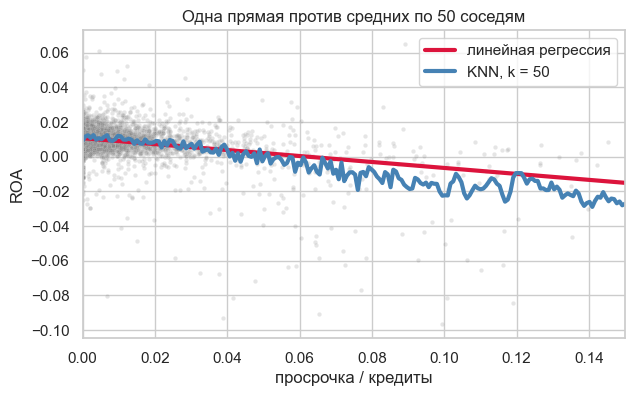

In [25]:
# Сетка: 200 точек от 0 до 15% просрочки — там живёт 99% банк-кварталов
grid = pd.DataFrame({"a_npl_gross_loans": np.linspace(0, 0.15, 200)})

sns.scatterplot(data=show, x="a_npl_gross_loans", y="e_roa", alpha=0.2, s=10, color="grey")
plt.plot(grid, linreg.predict(grid), color="crimson", lw=3, label="линейная регрессия")
plt.plot(grid, knn.predict(grid), color="steelblue", lw=3, label="KNN, k = 50")
plt.xlim(0, 0.15)
plt.title("Одна прямая против средних по 50 соседям")
plt.xlabel("просрочка / кредиты")
plt.ylabel("ROA")
plt.legend()
plt.show()

Красная прямая обязана быть прямой (поэтому регрессия и *линейная*): такую форму мы ей задали, один и тот же наклон на всём диапазоне, от хороших банков до преддефолтных.

Синяя линия строится по ближайшим соседям. До 4 % просрочки она почти совпадает с прямой: там банков много, и связь действительно близка к линейной. Дальше она уходит ниже прямой: при высокой просрочке прибыльность падает круче, чем обещает линейная модель. Ещё правее линия начинает дёргаться. Банков с такой просрочкой мало, 50 ближайших соседей набираются из широкого диапазона, и их средние шумят.

Возникает соблазн: раз гибкость помогает, давайте сделаем модель ещё гибче. Уменьшим $k$, пусть усредняет не по 50 соседям, а по одному.

In [26]:
# Цикл по разным k: каждый раз обучаем модель заново и считаем обе ошибки
rows = []
for k in [1, 5, 50, 500, 5000]:
    m = KNeighborsRegressor(n_neighbors=k).fit(X_train, y_train)
    rows.append({"соседей k": k,
                 "на обучающей": rmse(m, X_train, y_train),
                 "на тестовой":  rmse(m, X_test, y_test)})

pd.DataFrame(rows).set_index("соседей k").round(1)

,на обучающей,на тестовой
соседей k,,
1,37.1,148.8
5,97.2,117.0
50,106.5,108.0
500,107.6,107.1
5000,109.0,108.2


Прочитайте таблицу внимательно: в ней тот самый компромисс смещения и разброса (bias-variance tradeoff).

При $k = 1$ ошибка на обучающей выборке втрое меньше, чем у всех остальных. Каждая строка сама себе ближайший сосед, поэтому модель почти в точности воспроизводит данные, на которых училась, а на новых данных она худшая, хуже даже прямой: вместе с сигналом модель выучила случайный шум. При $k = 5000$ другая крайность: окрестность такая широкая, что различия между банками стираются, и ошибка снова растёт. Минимум посередине, в районе нескольких сотен соседей.

Это **переобучение** ($k = 1$) и **недообучение** ($k = 5000$) в одной таблице. Отсюда правило: **качество прогнозной модели меряют ошибкой на данных, которых она не видела**; $R^2$ и ошибка на обучающих данных для этого не годятся.

## Итого

1. Мы научились импортировать данные.
2. Провели описательный анализ: `.info()`, `.describe()`, гистограммы и корреляции. Выбросы нашли глазами и отфильтровали явным правилом.
3. Добавили в линейную регрессию взаимодействие: «эффект $X_1$ зависит от $X_2$». Читается оно по предельному эффекту на разных значениях $X_2$.
4. «Наклон разный» и «одно влияет на другое» — разные утверждения. Причинность мы не оценивали, только ассоциацию.
5. **Сравнивать модели можно только на данных, которых они не видели.**

---

# Домашнее задание

Базовый минимум: запустить ноутбук и прокликать его до этого момента без ошибок.

Роскошный максимум: выполнить те же клеточки, но с другим $Y$: вместо `e_roa` (прибыльность) взять `e_nim` (процентную маржу).

Если решитесь, копировать код из лекции можно и нужно, менять придётся немногое. Смысл задания в том, чтобы выбрать признаки, фильтр и $k$ и уметь объяснить каждый выбор.

### 1. Данные

`TODO(hw1-a)`. Загрузите `banks_panel.parquet` в переменную `hw` и напечатайте: число строк, число банков, период. В ячейке ниже, словами: что такое одна строка этой таблицы и почему строк намного больше, чем банков.

In [27]:
# TODO(hw1-a): загрузите панель в переменную `hw` и напечатайте её размер, число банков и период.


> _Ваш ответ (2–3 предложения):_

### 2. Посмотреть на данные

`TODO(hw1-b)`. Выберите четыре показателя, которые по вашей гипотезе связаны с процентной маржой, и постройте для них гистограммы (одна ячейка, цикл `for`, как в §2.3). Затем постройте корреляционную матрицу этих четырёх показателей вместе с `e_nim`.

Ниже словами: одно наблюдение, которое вас удивило, и одно, которое подтвердило ожидания.

In [28]:
# TODO(hw1-b): четыре гистограммы одним циклом + тепловая карта корреляций с e_nim.


> _Ваш ответ (2–3 предложения):_

### 3. Чистка

`TODO(hw1-c)`. Отфильтруйте панель в переменную `hw_clean`: условия выбираете сами, но каждое должно быть прокомментировано — почему именно эта граница. Напечатайте, сколько строк было и сколько осталось.

Ниже одним предложением: о какой совокупности банков теперь ваши выводы.

In [29]:
# TODO(hw1-c): постройте hw_clean явным фильтром; каждое условие с комментарием.
# Напечатайте: было строк / осталось строк / осталось банков.


> _Ваш ответ (1 предложение):_

### 4. Две регрессии

`TODO(hw1-d)`. Выберите два признака $X_1$ и $X_2$ из своих четырёх и оцените на `hw_clean`:

* `m_simple` — модель `e_nim ~ X1 + X2`;
* `m_inter` — та же модель со взаимодействием (`X1 * X2`).

Напечатайте таблицы коэффициентов, оба $R^2$ и предельный эффект $X_1$ на 10-м, 50-м и 90-м перцентилях $X_2$.

Напишите ~120 слов: что показывает взаимодействие, и — отдельным предложением — какое утверждение вы не имеете права сделать по этим оценкам.

In [30]:
# TODO(hw1-d): две модели statsmodels — `m_simple` и `m_inter` — на hw_clean,
# отклик e_nim. Напечатайте коэффициенты, R^2 обеих и предельный эффект X1
# на перцентилях 10 / 50 / 90 переменной X2.


> _Ваш ответ (~120 слов):_

### 5. Регрессия против соседей

`TODO(hw1-e)`. Разбейте `hw_clean` на обучающую и тестовую выборки (30% на тест, `random_state=SEED`). Предскажите `e_nim` по одному признаку двумя моделями: линейной регрессией и KNN при $k \in \{1, 5, 50, 500, 5000\}$. Соберите ошибки в таблицу `scores` (строки — модели, столбцы — обучающая и тестовая RMSE) и постройте картинку с обеими подгонками, как в §4.

Напишите ~80 слов: какое $k$ вы бы выбрали и почему не $k = 1$, хотя на обучающей выборке он лучший.

In [31]:
# TODO(hw1-e): train/test split, LinearRegression и KNN при разных k,
# таблица `scores` с обучающей и тестовой RMSE + график с двумя подгонками.


> _Ваш ответ (~80 слов):_